### imports

In [26]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import ast
from preprocessing import *

### Dataset Info - PTB XL

21799 total 
(9514 - NORM; 
5469 - MI)


12 leads

5 classes

Sample duration - 10 sec

Freq - 100 or 500 Hz

partitioned into 10 folders. "all records of a particular patient were assigned to the same fold"

### Loading dataset

In [2]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path_metadata = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\ptbxl_database.csv"
sampling_rate = 100
main_path = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\" #\\records"+str(sampling_rate)

In [3]:
#loadidng metadata
metadata_all_df = pd.read_csv(path_metadata, index_col='ecg_id')
metadata_all_df.scp_codes = metadata_all_df.scp_codes.apply(lambda x: ast.literal_eval(x))

In [5]:
#loading raw signal data
ecg_data = load_raw_data(metadata_all_df, sampling_rate, main_path)

In [6]:
print(ecg_data[1].shape)
print("12 leads & 1000 points from each lead(?)")

(1000, 12)
12 leads & 1000 points from each lead(?)


In [7]:
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(main_path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [8]:
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))


In [9]:
# Apply diagnostic superclass
metadata_all_df['diagnostic_superclass'] = metadata_all_df.scp_codes.apply(aggregate_diagnostic)

##### visualizing a few MI signals

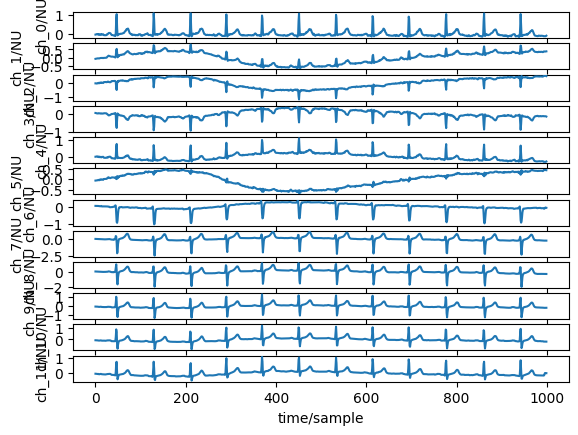

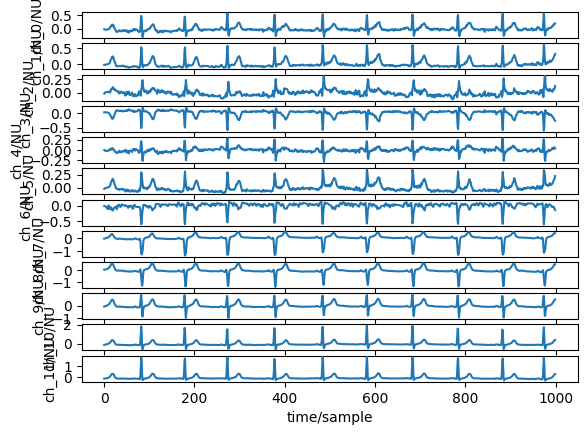

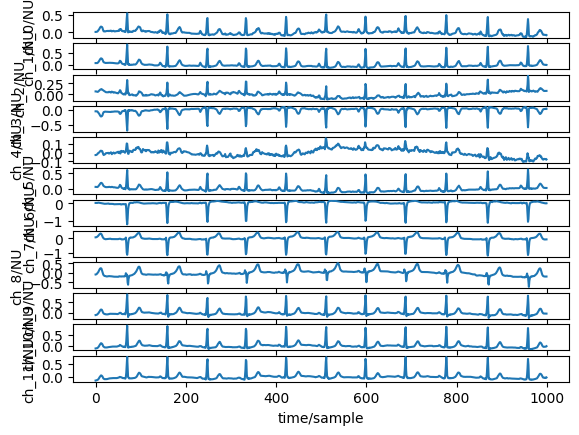

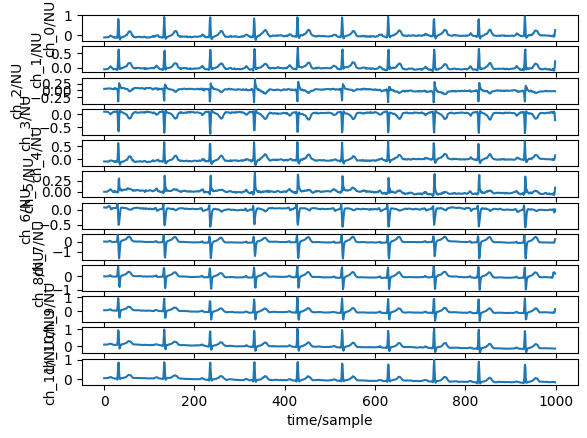

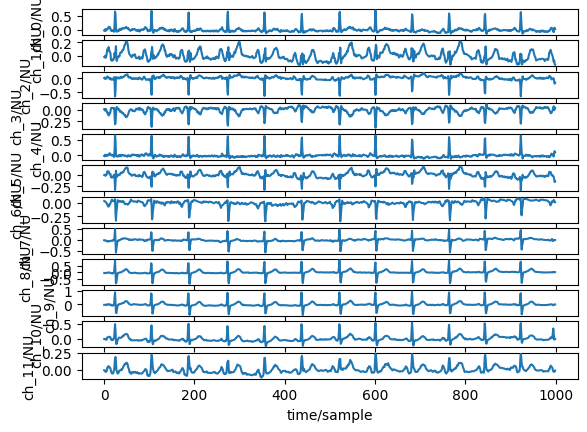

In [12]:
#loading 5 normal ecgs
for i in range(5):
    wfdb.plot.plot_items(signal=X_mi[i] )


##### visualizing a few Normal signals

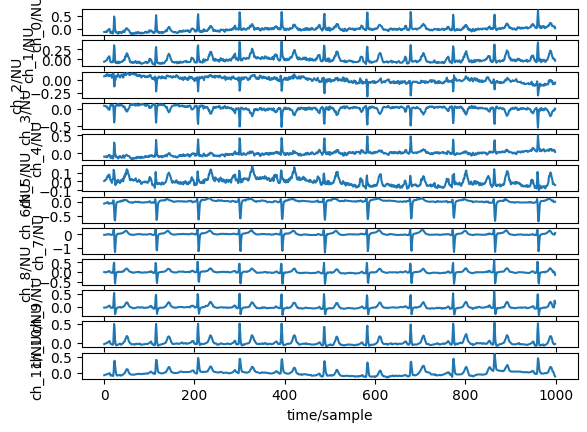

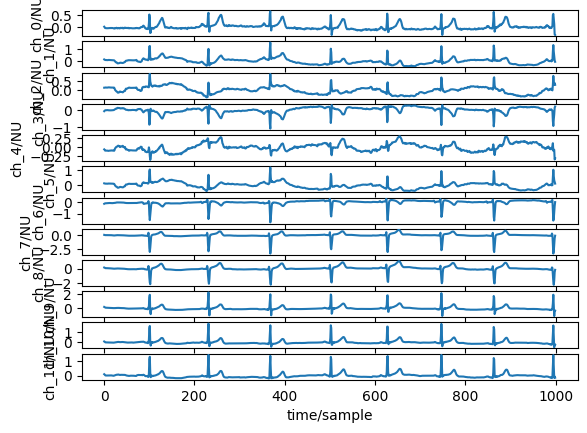

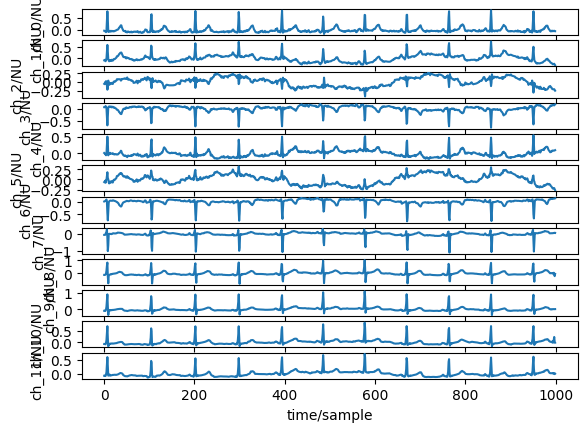

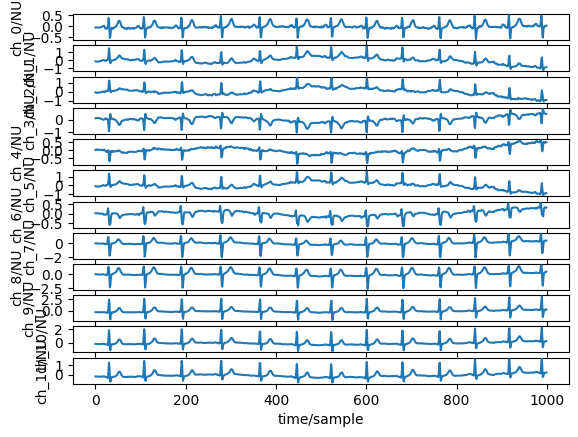

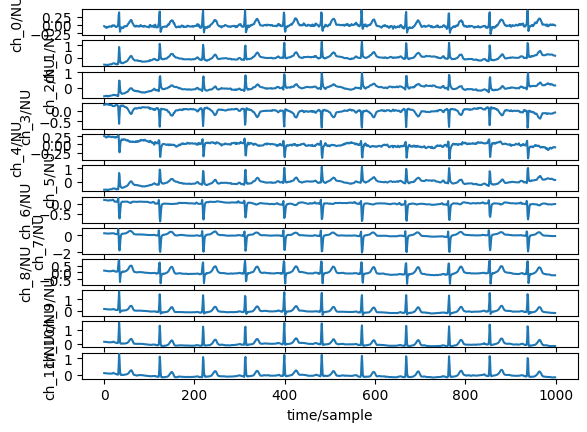

In [13]:
#loading 5 normal ecgs
for i in range(5):
    wfdb.plot.plot_items(signal=X_norm[i])


: 

: 

### Preprocessing


### splitting

In [66]:
import random

def split_ds(x, y, train_folds=7, val_folds=2, test_folds=1):

    folds = list(range(1, y["strat_fold"].max() + 1))
    random.shuffle(folds)

    train = folds[:train_folds]

    val = folds[
        train_folds :
        train_folds + val_folds
    ]

    test = folds[
        train_folds + val_folds :
    ]

    train_mask = y["strat_fold"].isin(train)
    val_mask = y["strat_fold"].isin(val)
    test_mask = y["strat_fold"].isin(test)

    return (
        (x[train_mask], y[train_mask]),
        (x[val_mask], y[val_mask]),
        (x[test_mask], y[test_mask]),
    )

In [107]:
mask = metadata_all_df["diagnostic_superclass"].isin([["NORM"], ["MI"]])

metadata = metadata_all_df[mask].copy()
X = ecg_data[mask]

metadata["label"] = (
    metadata["diagnostic_superclass"].apply(lambda x: x == ["MI"])
).astype(int)

train, val, test = split_ds(X, metadata)

raw_xtrain, ytrain = train
raw_xval, yval = val
raw_xtest, ytest = test

processed_xtrain = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtrain
])

processed_xval = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xval
])

processed_xtest = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtest
])

X_train, X_val, X_test, scaler = standardize_signals(
    processed_xtrain,
    processed_xval,
    processed_xtest
)

In [108]:
yval

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass,label
ecg_id,,,,,,,,,,,,,,,,,,,,,
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM],0
12,11031.0,43.0,1,NaN,44.0,2.0,0.0,CS-12 E,1984-12-21 08:02:26,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,8,records100/00000/00012_lr,records500/00000/00012_hr,[NORM],0
13,19953.0,58.0,1,NaN,54.0,2.0,0.0,CS-12 E,1985-01-05 12:13:05,sinusrhythmus normales ekg,...,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/00000/00013_lr,records500/00000/00013_hr,[NORM],0
43,11315.0,25.0,1,NaN,63.0,2.0,0.0,CS-12 E,1985-03-14 09:38:53,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,8,records100/00000/00043_lr,records500/00000/00043_hr,[NORM],0
46,13180.0,40.0,0,NaN,92.0,2.0,0.0,CS-12 E,1985-03-22 06:55:33,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00046_lr,records500/00000/00046_hr,[NORM],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21791,14999.0,58.0,1,NaN,NaN,0.0,0.0,CS100 3,2001-01-30 13:25:19,sinusrhythmus verdacht auf p-sinistrocardiale ...,...,NaN,NaN,NaN,NaN,NaN,8,records100/21000/21791_lr,records500/21000/21791_hr,[NORM],0
21807,21396.0,52.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-02-17 16:14:05,sinusrhythmus lagetyp normal normales ekg 4.46...,...,", I,II,",NaN,NaN,NaN,NaN,8,records100/21000/21807_lr,records500/21000/21807_hr,[NORM],0
21810,21295.0,56.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-02-18 16:12:42,sinusrhythmus lagetyp normal normales ekg 4.46...,...,NaN,NaN,NaN,NaN,NaN,2,records100/21000/21810_lr,records500/21000/21810_hr,[NORM],0


#### checking preprocessing on val set

## modelo

In [111]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping

# ===========================
# MODELO
# ===========================

model = Sequential([

    Input(shape=(1000, 12)),

    Bidirectional(
        LSTM(
            units=32,
            return_sequences=True
        )
    ),

    Bidirectional(
        LSTM(
            units=16,
            return_sequences=True
        )
    ),

    Bidirectional(
        LSTM(
            units=4,
            return_sequences=False
        )
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ===========================
# COMPILAÇÃO
# ===========================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

# ===========================
# EARLY STOPPING
# ===========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# ===========================
# TREINAMENTO
# ===========================

history = model.fit(
    X_train,
    ytrain['label'],
    validation_data=(X_val, yval['label']),
    epochs=50,
    batch_size=96,
    callbacks=[early_stop],
    verbose=1
)

# ===========================
# TESTE
# ===========================

results = model.evaluate(
    X_test,
    ytest['label'],
    verbose=1
)

print("\nResultados:")
for nome, valor in zip(model.metrics_names, results):
    print(f"{nome}: {valor:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1000, 64)       │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1000, 32)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 8)              │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,905 (93.38 KB)

 Trainable params: 23,905 (93.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 298s 3s/step - accuracy: 0.7761 - auc: 0.6253 - loss: 0.5193 - precision: 0.2432 - recall: 0.0101 - val_accuracy: 0.7844 - val_auc: 0.8684 - val_loss: 0.3723 - val_precision: 0.7500 - val_recall: 0.0462
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.8552 - auc: 0.8450 - loss: 0.3662 - precision: 0.7972 - recall: 0.4551 - val_accuracy: 0.8590 - val_auc: 0.8582 - val_loss: 0.3510 - val_precision: 0.7762 - val_recall: 0.5145
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.8478 - auc: 0.8146 - loss: 0.3818 - precision: 0.7477 - recall: 0.4612 - val_accuracy: 0.8581 - val_auc: 0.8752 - val_loss: 0.3523 - val_precision: 0.6895 - val_recall: 0.6590
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 301s 4s/step - accuracy: 0.8658 - auc: 0.8743 - loss: 0.3308 - precision: 0.7598 - recall: 0.5669 - val_accuracy: 0.8616 - val_auc: 0.8685 - val_loss: 0.3381 - val_precision: 0.7279 - val_recall: 0.6031
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━

In [110]:
print(X_train.shape)
print(ytrain['label'].shape)
print(X_val.shape)
print(X_test.shape)

(8121, 1000, 12)
(8121,)
(2333, 1000, 12)
(1147, 1000, 12)


In [1]:
import tensorflow as tf
tf.__version__

'2.21.0'